# 03 Detect

Turns the annual water / land masks into reclamation polygons with a `year` field, written to `data/processed/reclamation.gpkg`. All logic lives in `src/reclaim/detect.py`; parameters come from `config.yaml` (`detection`).

A pixel is reclaimed in year y when it is water in y-2 and y-1, land in y and y+1, and never water again up to 2026. Then:

1. clip to the Singapore boundary, which removes the Johor side
2. mask out OSM reservoirs and solar plants (`data/raw/reference/osm_reservoir_solar.json`); floating solar such as Tengeh turns water into apparent land
3. per year, a 1-pixel morphological opening and removal of patches under 0.5 ha
4. vectorise, one polygon per patch

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from reclaim import config, detect
from reclaim.config import RAW, ROOT
cfg = config.load()
crs = cfg['project']['crs']

## 1. Run

`summary` gives hectares per year after each step, so the effect of every filter is visible.

In [2]:
polys, summary = detect.run(cfg)
summary

wrote data/processed/reclamation.gpkg: 363 polygons, 2,430.8 ha


/opt/homebrew/Caskroom/miniforge/base/envs/sg-reclaim/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


,raw,in_boundary,no_reservoir_solar,cleaned
year,,,,
2016,450.4,307.6,301.6,156.8
2017,580.6,469.8,466.0,349.7
2018,443.5,386.0,384.7,324.8
2019,372.5,323.3,322.5,268.9
2020,341.1,308.6,306.1,238.7
2021,368.7,328.1,291.4,192.5
2022,493.0,451.4,413.8,330.2
2023,296.3,264.9,262.7,210.5
2024,266.9,212.7,209.6,142.0


## 2. Against SLA

SLA's total land area grew by 2,520 ha from 2015 to 2025. The detected total should be of the same order. Year-by-year numbers are not expected to match: SLA records land when it is surveyed and gazetted, the satellite sees it when it emerges from the water.

In [3]:
sla = pd.read_csv(RAW / 'reference' / 'sg_total_land_area.csv').set_index('year').total_land_area
by_year = summary[['cleaned']].rename(columns={'cleaned': 'detected_ha'})
by_year['sla_increase_ha'] = (sla.diff() * 100).reindex(by_year.index).round(1)
by_year.loc['total'] = by_year.sum()
print(f"detected {by_year.loc['total', 'detected_ha']:,.0f} ha, SLA 2015-2025 {(sla[2025] - sla[2015]) * 100:,.0f} ha")
by_year

detected 2,431 ha, SLA 2015-2025 2,520 ha


,detected_ha,sla_increase_ha
year,,
2016,156.8,60.0
2017,349.7,180.0
2018,324.8,270.0
2019,268.9,150.0
2020,238.7,260.0
2021,192.5,480.0
2022,330.2,120.0
2023,210.5,90.0
2024,142.0,50.0


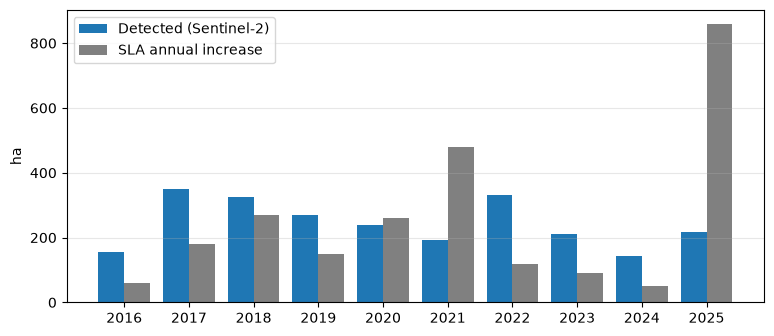

In [4]:
b = by_year.drop('total')
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(b))
ax.bar(x - 0.2, b.detected_ha, 0.4, label='Detected (Sentinel-2)')
ax.bar(x + 0.2, b.sla_increase_ha, 0.4, label='SLA annual increase', color='grey')
ax.set_xticks(x, b.index); ax.set_ylabel('ha'); ax.legend(); ax.grid(alpha=0.3, axis='y')

## 3. Map

Polygons coloured by detected year, on the 2015 land mask.

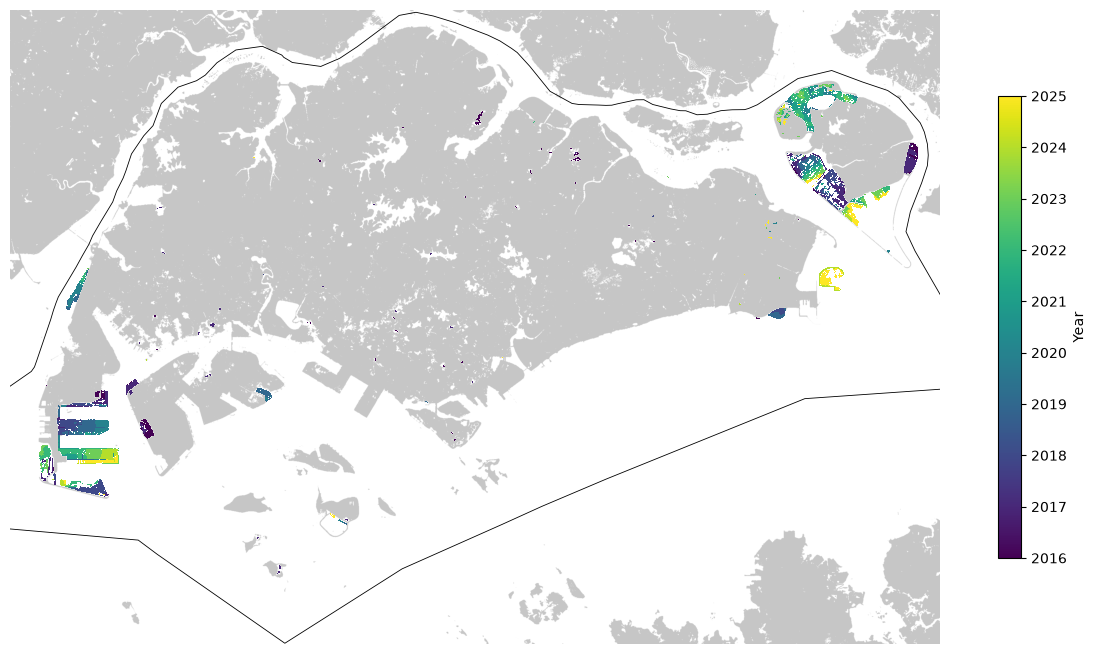

In [5]:
import rasterio
from reclaim.classify import MASKS
with rasterio.open(MASKS / 'mask_2015.tif') as src:
    land15 = src.read(1) == 0
    b_ = src.bounds
boundary = gpd.read_file(ROOT / cfg['aoi']['boundary_file']).to_crs(crs)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(np.ma.masked_equal(land15, False), cmap='Greys', vmin=0, vmax=3, extent=(b_.left, b_.right, b_.bottom, b_.top))
boundary.boundary.plot(ax=ax, color='k', lw=0.6)
polys.plot(ax=ax, column='year', cmap='viridis', legend=True, legend_kwds={'shrink': 0.6, 'label': 'Year'})
ax.set_xlim(b_.left, b_.right); ax.set_ylim(b_.bottom, b_.top); ax.set_axis_off()

## 4. Known projects

Hectares detected within 1.5 km of each site, by year. Every site should show up.

In [6]:
to = Transformer.from_crs('EPSG:4326', crs, always_xy=True)
sites = {'Tuas port': (103.630, 1.240), 'Tekong polder (NW)': (104.035, 1.426), 'Tekong south-west': (104.030, 1.385),
         'Changi south coast': (104.0105, 1.3124), 'Changi offshore': (104.0403, 1.3314)}
site_geom = gpd.GeoDataFrame({'site': list(sites)}, geometry=gpd.points_from_xy(*zip(*[to.transform(*v) for v in sites.values()])), crs=crs)
site_geom['geometry'] = site_geom.buffer(1500)
hits = gpd.overlay(polys, site_geom, how='intersection')
hits.assign(ha=hits.area / 1e4).pivot_table(index='site', columns='year', values='ha', aggfunc='sum', fill_value=0, margins=True, margins_name='total').round(1)

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,total
site,,,,,,,,,,,
Changi offshore,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0,64.2,95.2
Changi south coast,1.8,0.0,18.8,29.0,0.0,0.0,0.0,0.0,0.0,0.0,49.7
Tekong polder (NW),0.0,0.0,0.0,2.3,48.8,79.0,87.7,18.7,0.0,1.9,238.3
Tekong south-west,7.9,36.1,81.4,36.5,27.5,29.1,23.9,22.0,5.4,12.0,281.8
Tuas port,0.0,0.0,43.4,107.7,32.1,34.7,70.3,55.7,21.7,27.2,392.9
total,9.8,36.1,143.6,175.6,108.4,142.8,181.9,96.4,58.2,105.3,1057.9


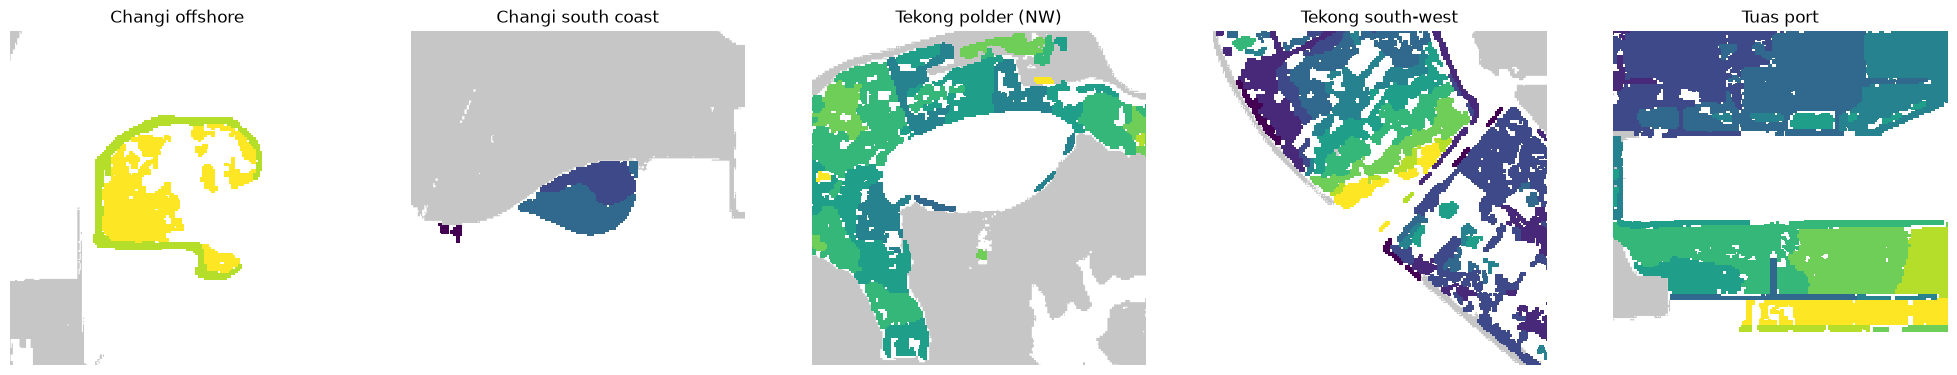

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5.5))
for ax, (name, g) in zip(axes, site_geom.groupby('site')):
    ax.imshow(np.ma.masked_equal(land15, False), cmap='Greys', vmin=0, vmax=3, extent=(b_.left, b_.right, b_.bottom, b_.top))
    polys.plot(ax=ax, column='year', cmap='viridis', vmin=2016, vmax=2025)
    x0, y0, x1, y1 = g.total_bounds; ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(name); ax.set_axis_off()

## 5. Checks

- No polygon outside the Singapore boundary (Johor side).
- No polygon on an OSM reservoir or solar plant.
- Effect of the exclusion: the drop between `in_boundary` and `no_reservoir_solar` above, mostly the Tengeh floating solar farm in 2021-2022.

In [8]:
excl = detect.exclusions(cfg)
outside = polys[~polys.within(boundary.union_all().buffer(1))]
on_excl = gpd.overlay(polys, gpd.GeoDataFrame(geometry=excl), how='intersection')
print(f'polygons outside the boundary: {len(outside)}')
print(f'area on reservoirs / solar plants: {on_excl.area.sum() / 1e4:.2f} ha')
print(f"removed by the exclusion: {(summary.in_boundary - summary.no_reservoir_solar).sum():.1f} ha")

polygons outside the boundary: 0
area on reservoirs / solar plants: 0.02 ha
removed by the exclusion: 98.8 ha


## 6. Remaining inland detections

Small ponds inside the main island that were filled during development are not reservoirs, so the OSM layer does not remove them. They are mostly in 2016, where the rule relies on the weakest masks (Landsat 2014 and Sentinel-2 2015). The cell below measures them as polygons lying in water that the 2015 main-island land completely enclosed. This rule is a check only: it would also remove bunded basins inside Tuas that are real reclamation.

In [9]:
from scipy import ndimage as ndi
from reclaim.classify import inside_boundary
with rasterio.open(MASKS / 'mask_2015.tif') as src:
    transform = src.transform
land_sg = land15 & inside_boundary(cfg, land15.shape, transform)
lab, n = ndi.label(land_sg)
main = lab == np.argmax(np.bincount(lab.ravel())[1:]) + 1
enclosed = ndi.binary_fill_holes(main) & ~main
c = polys.representative_point()
cols, rows = ~transform * (c.x.values, c.y.values)
polys['enclosed_2015'] = enclosed[rows.astype(int), cols.astype(int)]
print(f"{polys.enclosed_2015.sum()} polygons, {polys[polys.enclosed_2015].area_ha.sum():.1f} ha in enclosed water")
polys[polys.enclosed_2015].groupby('year').area_ha.agg(['count', 'sum']).round(1)

42 polygons, 62.2 ha in enclosed water


,count,sum
year,,
2016,28,50.1
2017,10,9.4
2018,1,0.6
2024,1,0.7
2025,2,1.4
